In [1]:
import pandas as pd
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import statsmodels.api as sm
from numpy import loadtxt
import joblib
from keras.models import Sequential
from keras.layers import Dense
from keras import layers, models
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dropout, Dense
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
from numpy import loadtxt
from keras_tuner import Hyperband
from sklearn.preprocessing import MinMaxScaler

In [2]:
SEED_VALUE = 42
os.environ["PYTHONHASHSEED"] = str(SEED_VALUE)
random.seed(SEED_VALUE)

np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# CRISP-DM Framework
## 1. Business Understanding

##### In the CRISP-DM framework, the Business Understanding phase defines the business problem and translates it into a data mining task (Shearer, 2000). 
##### The large number of cybersecurity alerts makes manual threat prioritization difficult and time-consuming. then comes the question, How can machine learning models classify automatically and accurately cybersecurity alerts into discrete threat severity levels?.
##### Therefore, this study addresses the problem as a multiclass classification task to automatically predict threat severity based on its characteristics (Shearer, 2000; Marbán et al., 2009). 
##### The study aims to classify threats into three severity levels: Low, Medium, and Critical.

## 2. DATA UNDERSTANDING
##### The second phase is Data Understanding, which focuses on examining the available data, its features, class distribution, and data quality (Shearer, 2000). 
##### This study uses the Federated Cyber Threat Intelligence Dataset. It was downloaded from Kaggle and examined for its features, class distribution, and data quality.
##### The dataset contains 27 numerical and 10 categorical features. The original target (threat_severity) contained 4 severity levels: Low, Medium, High and Critical. 

In [3]:
# # Download latest version
# path = kagglehub.dataset_download("colabsss/cyber-threat-intelligence-dataset")
# print("Path to dataset files:", path)

df = pd.read_csv("/Users/ws/Documents/DataScienceCourse/data/Semmler_Exam2_MADS2/data/Federated_Cyber_Threat_Intelligence_Dataset.csv")
print(df.columns)
# df.info()

num = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat = df.select_dtypes(include=["object", "string"]).columns.tolist()

cat2 = ["source_port", "destination_port"]
timestamp = ["timestamp"]

numerical = [col for col in num if col not in cat2]
categorical = [col for col in (cat + cat2) if col != "timestamp"]

print("Numerical features:", numerical)
print("Categorical features:", categorical)

Index(['event_id', 'organization_id', 'agent_id', 'timestamp', 'network_zone',
       'protocol_type', 'service_type', 'source_port', 'destination_port',
       'connection_duration_ms', 'packet_count', 'byte_count', 'packet_rate',
       'byte_rate', 'inbound_traffic_ratio', 'outbound_traffic_ratio',
       'failed_login_count', 'authentication_attempts',
       'system_call_frequency', 'process_count', 'cpu_usage_pct',
       'memory_usage_pct', 'file_access_count', 'registry_change_count',
       'dns_query_frequency', 'connection_failure_rate',
       'unusual_port_activity', 'payload_entropy', 'traffic_anomaly_score',
       'behavioral_risk_score', 'threat_indicator_count',
       'historical_attack_frequency', 'local_model_confidence',
       'privacy_noise_level', 'model_update_size_kb',
       'communication_latency_ms', 'threat_severity', 'threat_category'],
      dtype='str')
Numerical features: ['connection_duration_ms', 'packet_count', 'byte_count', 'packet_rate', 'byte_ra

### 2.1 Missing Value
##### no missing value found

In [4]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

print("Total missing values:", df.isna().sum().sum())

Missing values per column:
Series([], dtype: int64)
Total missing values: 0


### 2.2 Outlier
##### Boxplot shows theres highly skewed numerical variables, such: packet_count, byte_count, packet_rate, byte_rate, failed_login_count, and connection_failure_rate.
##### These skewed features were later preprocessed using log1p transformation to stabilize variance, followed by Min-Max scaling to normalize into a uniform 0–1 range, for ANN.
##### But the tree-based architectures such, Random Forest and XGBoost split data step-by-step and handle non-linear relationships natively and require no such feature transformation.

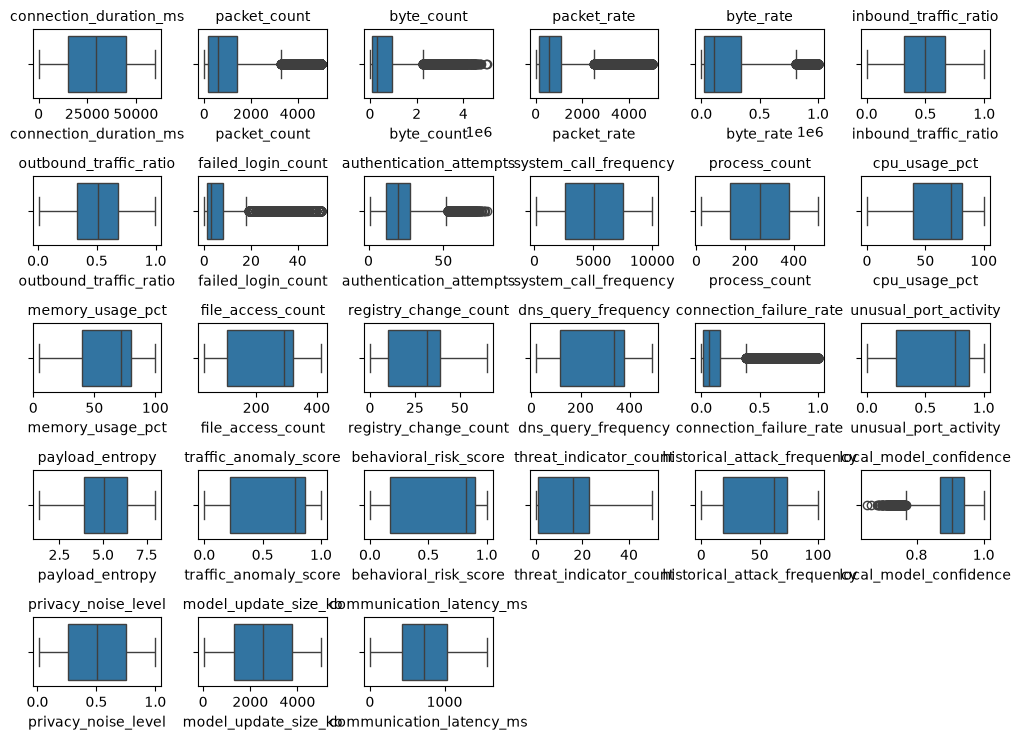

In [5]:
import math

skewed_features = [
    col for col in numerical if df[col].mean() > (df[col].median() * 1.5)
]
cols = 6
rows = math.ceil(len(numerical) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(10, rows * 1.5))
axes = axes.flatten()

for i, col in enumerate(numerical):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

[fig.delaxes(axes[j]) for j in range(len(numerical), len(axes))]
plt.tight_layout()
plt.show()


### 2.3 ChiSquared Categorical Feature Significant
##### A Pearson’s Chi-Square was conducted to evaluate the relationship between categorical features and the target variable [threat_severity], using a significance threshold of \(\alpha = 0.05\).
##### 7 Categorical variables that showed no significant association with threat severity such; event_id, organization_id, agent_id, protocol_type, service_type, source_port, and destination_port, were considered excluded from modeling phase.

In [6]:
from scipy.stats import chi2_contingency

target_var = "threat_severity"

for feature in categorical:
    if feature == target_var:
        continue

    contingency_table_cat = pd.crosstab(df[feature], df[target_var])
    chi2_stat, p_val, dof, expected_freqs = chi2_contingency(contingency_table_cat)

    print(f"--- Chi-Square Test: {feature} vs {target_var} ---")
    print(f"X-squared: {chi2_stat:.3f}")
    print(f"p-value: {p_val:.8f}")

    if p_val < 0.05:
        print("Result: Statistically SIGNIFICANT (Keep this feature)\n")
    else:
        print("Result: NOT significant (Consider excluded from model)\n")

--- Chi-Square Test: event_id vs threat_severity ---
X-squared: 45000.000
p-value: 0.49512409
Result: NOT significant (Consider excluded from model)

--- Chi-Square Test: organization_id vs threat_severity ---
X-squared: 23.133
p-value: 0.67783360
Result: NOT significant (Consider excluded from model)

--- Chi-Square Test: agent_id vs threat_severity ---
X-squared: 309.994
p-value: 0.29018801
Result: NOT significant (Consider excluded from model)

--- Chi-Square Test: network_zone vs threat_severity ---
X-squared: 23.260
p-value: 0.00563715
Result: Statistically SIGNIFICANT (Keep this feature)

--- Chi-Square Test: protocol_type vs threat_severity ---
X-squared: 13.478
p-value: 0.33524704
Result: NOT significant (Consider excluded from model)

--- Chi-Square Test: service_type vs threat_severity ---
X-squared: 13.700
p-value: 0.54842396
Result: NOT significant (Consider excluded from model)

--- Chi-Square Test: threat_category vs threat_severity ---
X-squared: 15144.103
p-value: 0.000

### 2.4 ChiSquared Numerical Feature Significant
##### A Pearson’s Chi-Square was conducted to evaluate the relationship between numerical features and the target variable [threat_severity].
##### 6 Numerical features such; packet_count, byte_count, packet_rate, byte_rate, failed_login_count, and connection_failure_rate showed skewness. For ANN, these 6 features need to be stabilized using log1p and min-max scaling, but not for tree architectures.
##### The remaining 21 features showed well-distributed, balanced profiles and were ready for immediate use.

In [7]:
for feature in numerical:
    stats = df[feature].describe()
    mean_val = stats["mean"]
    median_val = stats["50%"]

    # If mean is significantly larger than the median, it has high outliers
    if mean_val > (median_val * 1.5):
        print(f" {feature:<30} -> HEAVILY SKEWED! (Needs scale for ANN)")
    else:
        print(f" {feature:<30} -> Normal & Balanced (Ready to use)")


 connection_duration_ms         -> Normal & Balanced (Ready to use)
 packet_count                   -> HEAVILY SKEWED! (Needs scale for ANN)
 byte_count                     -> HEAVILY SKEWED! (Needs scale for ANN)
 packet_rate                    -> HEAVILY SKEWED! (Needs scale for ANN)
 byte_rate                      -> HEAVILY SKEWED! (Needs scale for ANN)
 inbound_traffic_ratio          -> Normal & Balanced (Ready to use)
 outbound_traffic_ratio         -> Normal & Balanced (Ready to use)
 failed_login_count             -> HEAVILY SKEWED! (Needs scale for ANN)
 authentication_attempts        -> Normal & Balanced (Ready to use)
 system_call_frequency          -> Normal & Balanced (Ready to use)
 process_count                  -> Normal & Balanced (Ready to use)
 cpu_usage_pct                  -> Normal & Balanced (Ready to use)
 memory_usage_pct               -> Normal & Balanced (Ready to use)
 file_access_count              -> Normal & Balanced (Ready to use)
 registry_change_count 

### 2.5 Target Feature Selection

##### A multi-output classification framework was initially considered to predict two targets simultaneously to answer if machine learning models can automatically and accurately classify cybersecurity alerts contain both threat severity levels and threat categories?.
##### However, the bias-corrected Cramér’s V test revealed a strong association of 0.58 between them. To prevent data leakage, the architecture was simplified to a single target feature, and the secondary target feature was dropped from the pipeline.
##### threat_severity was selected as the final target over threat_category due to two primary factors:
##### 1. Severity tells the security team what to fix first. Knowing how dangerous an attack is (Critical vs. Low) is more urgent than knowing the exact type of attack.
##### 2. Splitting the data into an 8-class target_categories makes the model confused and leads to overfitting.
##### The statistical test between threat_category and threat_severity proves they are strongly tied together. 
##### 1. p-value = 0.0: Proves with 100% certainty that the relationship between the two features is real and not a random accident.
##### 2. Chi-Square = 15,144.10: A high score indicating that specific attack categories map directly to predictable severity levels.

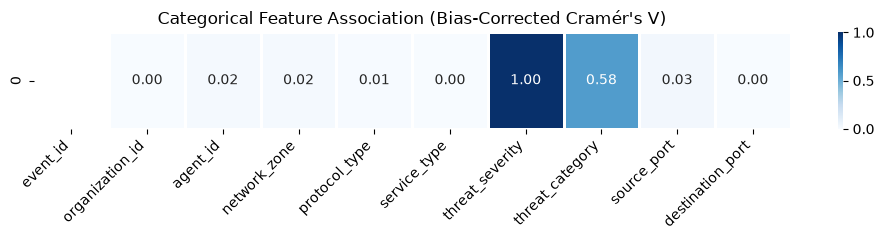

In [8]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)

    if table.shape[0] < 2 or table.shape[1] < 2:
        return 0.0

    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.values.sum()
    r, k = table.shape

    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    r_corr = r - (r-1)**2/(n-1)
    k_corr = k - (k-1)**2/(n-1)

    return np.sqrt(phi2_corr / min(r_corr-1, k_corr-1))

scores = pd.DataFrame({
    f: [cramers_v(df[f], df["threat_severity"])]for f in categorical})

plt.figure(figsize=(10, 2.5))
sns.heatmap(scores, annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=1, linewidths=1)
plt.title("Categorical Feature Association (Bias-Corrected Cramér's V)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [9]:
table = pd.crosstab(df["threat_category"], df["threat_severity"])
chi2, p, dof, expected = chi2_contingency(table)
n = table.sum().sum()
phi2 = chi2 / n
r, k = table.shape
cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))
print("--- Relation Test: threat_category vs threat_severity ---")
print("Cramer's V:", cramers_v)
print("Chi-square:", chi2)
print("p-value:", p)


--- Relation Test: threat_category vs threat_severity ---
Cramer's V: 0.5801169060005767
Chi-square: 15144.103108245694
p-value: 0.0


### 2.6 Examine Target Feature Class Distribution
##### The original target feature [threat_severity] contains 4 classes with such distribution: Low (30.4%), Medium (22.0%), High (31.7%), and Critical (16.0%).
##### To evaluate the separability of these classes, a t-SNE projection (perplexity=30) was visualized.
##### Observation: TSNE projects, while the Low (green cluster) and Medium (yellow cluster) classes display clear, distinct spatial separation, the High (orange) and Critical (red) classes shows overlapping behavioral patterns. 
##### Consideration: To resolve overlap classes, High and Critical categories were consider to be merged into a single High/Critical class. This reduces the target into a clean 3-class classification problem (Low, Medium, and Critical).

In [10]:
severity_distribution = (df["threat_severity"]
                         .value_counts().reindex(["Low", "Medium", "High", "Critical"]).to_frame("Count"))
severity_distribution["Percentage"] = (severity_distribution["Count"] / len(df) * 100)
print(severity_distribution)

                 Count  Percentage
threat_severity                   
Low               4553   30.353333
Medium            3298   21.986667
High              4749   31.660000
Critical          2400   16.000000


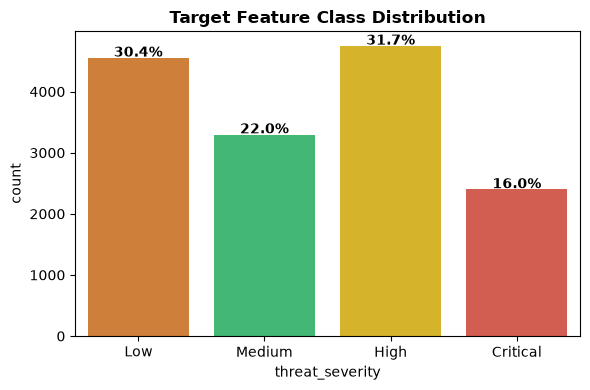

In [11]:
plt.figure(figsize=(6, 4))
order = ["Low", "Medium", "High", "Critical"]
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]

ax2 = sns.countplot(
    x="threat_severity", data=df, order=order, hue="threat_severity",
    palette=colors, legend=False, stat="count")

for i, p in enumerate(ax2.patches):
    pct = (p.get_height() / len(df)) * 100
    ax2.annotate(f"{pct:.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height() + 20),
        ha="center", fontweight="bold")

plt.title("Target Feature Class Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


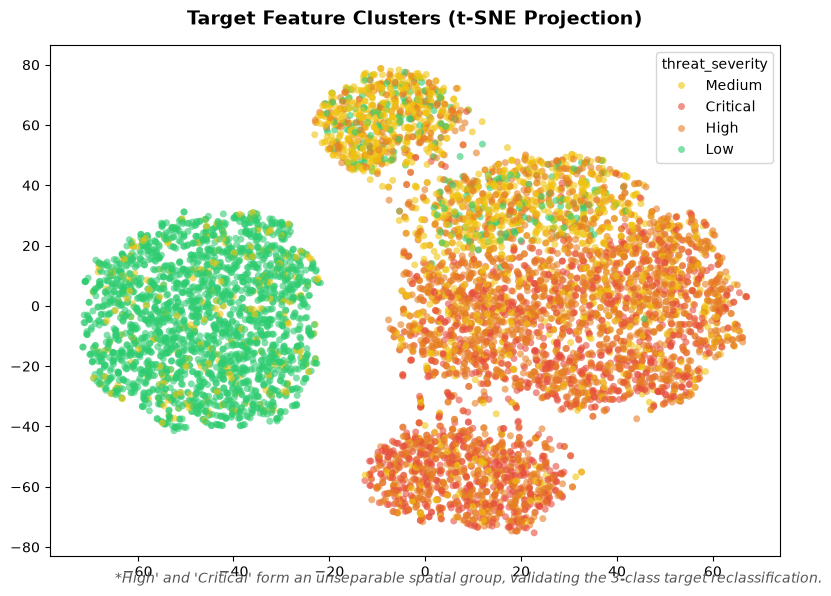

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

target = 'threat_severity'

def plot_tsne_clustering(data, feature_cols, target_col):
    X_scaled = StandardScaler().fit_transform(data[feature_cols])
    X_tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42).fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    colors = {"Low": "#2ecc71", "Medium": "#f1c40f", "High": "#e67e22", "Critical": "#e74c3c"}

    sns.scatterplot(
        x=X_tsne[:, 0],y=X_tsne[:, 1],hue=data[target_col],palette=colors,alpha=0.6,edgecolor="none",s=25,)

    plt.title(
        "Target Feature Clusters (t-SNE Projection)", fontsize=14, fontweight="bold", pad=15,)
    
    plt.figtext(
        0.15, 0.02,
        "*High' and 'Critical' form an unseparable spatial group, validating the 3-class target reclassification.",
        fontsize=10, style="italic", color="#555555")
    
    plt.tight_layout()
    plt.show()

plot_tsne_clustering(df.sample(8000, random_state=42), numerical, target)

## 3. Data Preparation

### 3.1 RE-CLASSIFIY TARGET CLASS
##### Based on the t-SNE analysis, the High and Critical classes were merged into one Critical class, resulting in three target classes: Low, Medium, and Critical.

In [13]:
df["severity_3class"] = df["threat_severity"].replace(
    {"High": "Critical", "Critical": "Critical"})

print("Original classes:")
print(df["threat_severity"].unique())

print("\n3-class target:")
print(df["severity_3class"].unique())

Original classes:
<ArrowStringArray>
['Medium', 'High', 'Low', 'Critical']
Length: 4, dtype: str

3-class target:
<ArrowStringArray>
['Medium', 'Critical', 'Low']
Length: 3, dtype: str


### 3.2 Feature Selection
##### Based on  results from Chi-square tests and Cramér's V , features with no significant association with threat severity were excluded

In [14]:
# TARGET FEATURES

X = df.drop(columns=[
    "threat_severity", "severity_3class", 'threat_category',
    "event_id", "organization_id", "agent_id", "timestamp", 
    'destination_port', 'source_port', 'service_type', 'protocol_type'])

numerical = X.select_dtypes(include=["int64", "float64"]).columns
categorical = X.select_dtypes(include=["object", "string"]).columns

### 3.3 Encode Target Feature
##### The three target classes were encoded into numerical labels using LabelEncoder. This converts the categorical severity labels into numerical values required by the machine learning models.


In [15]:
# ENCODE 3-CLASS TARGET

le_severity_3 = LabelEncoder()
y_severity_3 = le_severity_3.fit_transform(df["severity_3class"])

print("\nEncoded classes:")
print(le_severity_3.classes_)


Encoded classes:
['Critical' 'Low' 'Medium']


### 3.4 Prepocessor
##### A preprocessing pipeline was created to convert categorical features into numerical values using One-Hot Encoding.
##### Numerical features were passed through unchanged.

In [16]:
# PREPROCESSOR

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(
        handle_unknown="ignore"), categorical)], remainder="passthrough")

### 3.5 Split data into train and test

In [17]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y_severity_3,              
    test_size=0.2, random_state=42, stratify=y_severity_3)

## 4. Modelling
##### CRISP-DM recommends evaluating multiple modeling techniques because different algorithms may produce different levels of predictive performance depending on the characteristics of the dataset (Shearer, 2000; Marbán et al., 2009). 
##### The Modeling phase consisted of selecting, configuring, and training three machine learning models: Random Forest (RF), XGBoost (XGB), and Artificial Neural Network (ANN). 
##### These models were selected because ensemble tree methods such as RF and XGB are widely used for structured cybersecurity classification, while ANN can learn complex nonlinear relationships in security data (Sow & Mehdi, 2025; Sarker et al., 2021). 

### 4.1 Model 1 Random Forest
##### RF model demonstrates strong prediction with an average AUC of 0.87 and a test accuracy of 79.6% and its indicating mild overfitting.
##### Problem found in classifying Medium target Severity: Performance drops significantly for the Medium class (0.51 F1-score). The confusion matrix reveals a clear overlap challenge, where 260 Medium threats were misclassified as Critical, and 169 Critical threats were misclassified as Medium.

RF Threat Severity Report:
               precision    recall  f1-score   support

    Critical       0.83      0.88      0.85      1430
         Low       0.91      0.89      0.90       911
      Medium       0.54      0.48      0.51       659

    accuracy                           0.80      3000
   macro avg       0.76      0.75      0.75      3000
weighted avg       0.79      0.80      0.79      3000

RF Confusion Matrix:
 [[1261    0  169]
 [   4  811   96]
 [ 260   82  317]]

RF Train Accuracy: 0.8726
RF Test Accuracy:  0.7963
Average AUC: 0.8710934279162079


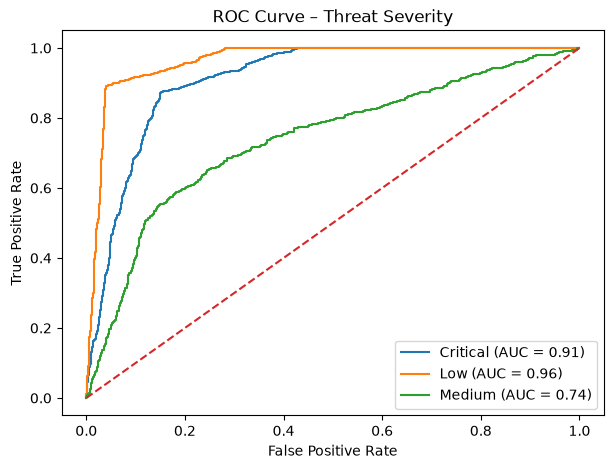

In [18]:

rf = RandomForestClassifier(
    n_estimators=150, max_depth=15, 
    min_samples_leaf=4, random_state=42, n_jobs=-1)

rfmodel = Pipeline([('preprocessor', preprocessor), ('classifier', (rf))])

# Training
rfmodel.fit(X_train, y_train)
y_pred_rf = rfmodel.predict(X_test)

## EVALUATION

print("RF Threat Severity Report:\n", classification_report(y_test, y_pred_rf, target_names=le_severity_3.classes_))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Accuracy
train_accuracy = rfmodel.score(X_train, y_train)
test_accuracy = rfmodel.score(X_test, y_test)
print(f"\nRF Train Accuracy: {train_accuracy:.4f}")
print(f"RF Test Accuracy:  {test_accuracy:.4f}")

# ## CROSS VALIDATION

y_prob_rf = rfmodel.predict_proba(X_test)

# roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
print("Average AUC:", roc_auc_score(y_test, y_prob_rf, multi_class="ovr", average="macro"))

# Convert y_test into binary columns for each class
y_test_bin = label_binarize(y_test, classes=range(len(le_severity_3.classes_)))

# ROC CURVE

plt.figure(figsize=(7, 5))

for i, class_name in enumerate(le_severity_3.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Threat Severity")
plt.legend()
plt.show()




### 4.1.1 Random Forest Hyperparameter using GRIDSearchCV
##### Despite tuning, the model still struggles to clearly separate the Medium and Critical classes. The confusion matrix shows 254 Medium threats were still misclassified as Critical, and 171 Critical threats were misclassified as Medium.

In [19]:
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV


# HYPERTUNE RANDOM FOREST

rf_param_grid = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__max_depth": [10, 15, 20],
    "classifier__min_samples_leaf": [2, 4, 6]
}

rf_grid = GridSearchCV(
    rfmodel,
    rf_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

# Tune using TRAINING data only
rf_grid.fit(X_train, y_train)

print("\nBEST RF PARAMETERS:\n", rf_grid.best_params_)
print("\nBEST RF CV MACRO-F1:\n", rf_grid.best_score_)

# Final prediction on untouched TEST set
y_pred_rf_grid = rf_grid.predict(X_test)

print("\n-HYPERTUNE RANDOM FOREST-")
print(classification_report(y_test, y_pred_rf_grid, target_names=le_severity_3.classes_))

print("\nRF Grid Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_grid))

print(f"Train Accuracy: {accuracy_score(y_train, rf_grid.predict(X_train)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_rf_grid):.4f}")
print("\nTest Macro-F1\n:", f1_score(y_test, y_pred_rf_grid, average="macro"))

# Get predicted probabilities
y_prob_rf_grid = rf_grid.predict_proba(X_test)

# roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
print("Average AUC:", roc_auc_score(y_test, y_prob_rf_grid, multi_class="ovr", average="macro"))



Fitting 5 folds for each of 27 candidates, totalling 135 fits

BEST RF PARAMETERS:
 {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 6, 'classifier__n_estimators': 200}

BEST RF CV MACRO-F1:
 0.7524808396611383

-HYPERTUNE RANDOM FOREST-
              precision    recall  f1-score   support

    Critical       0.83      0.88      0.86      1430
         Low       0.91      0.89      0.90       911
      Medium       0.55      0.49      0.52       659

    accuracy                           0.80      3000
   macro avg       0.76      0.75      0.76      3000
weighted avg       0.79      0.80      0.79      3000


RF Grid Confusion Matrix:
 [[1259    0  171]
 [   2  811   98]
 [ 254   82  323]]
Train Accuracy: 0.8181
Test Accuracy:  0.7977

Test Macro-F1
: 0.7568361538306224
Average AUC: 0.873722850683848


### 4.2 Model 2 XGB

##### XGB model achieves an average AUC of 0.8765, which is identical to the Random Forest RF performance. From (train score: 79.71%  vs. test score: 79.60%), XGB successed to eliminate the mild overfitting gap. 
##### The Medium class remains the main concern for XGB (0.51 F1-score). This tells that the remaining mistakes are caused by messy or overlapping data points rather than the algorithms themselves.


--- XGBOOST 3-CLASS SEVERITY ---
              precision    recall  f1-score   support

    Critical       0.83      0.88      0.85      1430
         Low       0.91      0.89      0.90       911
      Medium       0.55      0.48      0.51       659

    accuracy                           0.80      3000
   macro avg       0.76      0.75      0.75      3000
weighted avg       0.79      0.80      0.79      3000


XGB Confusion Matrix:
 [[1261    1  168]
 [   5  811   95]
 [ 261   82  316]]

XGB Train Accuracy: 0.7971
XGB Test Accuracy:  0.7960
Average AUC: 0.8756155359234555


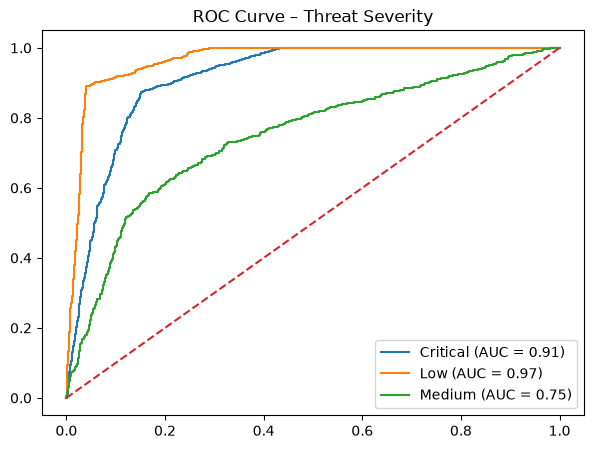

In [20]:
# XGBOOST

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_lambda=5,
    reg_alpha=1,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model = Pipeline([("preprocessor", preprocessor), ("classifier", xgb)])

# TRAINING

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)

# EVALUATION

print("\n--- XGBOOST 3-CLASS SEVERITY ---")
print(classification_report(y_test, y_pred_xgb, target_names=le_severity_3.classes_))
print("\nXGB Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# Accuracy
train_accuracy = xgb_model.score(X_train, y_train)
test_accuracy = xgb_model.score(X_test, y_test)

print(f"\nXGB Train Accuracy: {train_accuracy:.4f}")
print(f"XGB Test Accuracy:  {test_accuracy:.4f}")

# ROC CURVE
print("Average AUC:", roc_auc_score(y_test, y_prob_xgb, multi_class="ovr", average="macro"))

y_test_bin = label_binarize(y_test, classes=range(len(le_severity_3.classes_)))

plt.figure(figsize=(7, 5))

for i, class_name in enumerate(le_severity_3.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve – Threat Severity")
plt.legend()
plt.show()

### 4.2.1 XGB Hyperparameter using GRIDSearchCV
#####  The grid search were designed to explore what worked best by testing more trees (up to 300) and keeping depth structures simple of 2–4, while adding strict randomness (0.6–0.7 sampling) and a built data filter (reg_alpha) to help the model to stop mixing up Medium and Critical threats. 
##### Based on above parameters, 324 model setup were performed with 5-fold cross validation. 
##### Result shows, 255 Medium cases were misclassified as Critical, and 82 were misclassified as Low, means tuned XGBoost trees still failed to significantly clear up Medium class.


In [21]:
xgb_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [2, 3, 4],
    "classifier__learning_rate": [0.01, 0.03, 0.05],
    "classifier__subsample": [0.6, 1.0],
    "classifier__colsample_bytree": [0.6, 1.0],
    "classifier__reg_alpha": [0, 0.1, 1.0] 
}


xgb_grid = GridSearchCV(
    xgb_model,
    xgb_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

# Tune TRAINING data 
xgb_grid.fit(X_train, y_train)

print("\nBEST XGBOOST PARAMETERS:\n", xgb_grid.best_params_)
print("\nBEST XGBOOST CV MACRO-F1:\n", xgb_grid.best_score_)

# prediction on TEST set
y_pred_xgb_grid = xgb_grid.predict(X_test)

print("\n-HYPERTUNE XGBOOST-")
print(classification_report(y_test, y_pred_xgb_grid, target_names=le_severity_3.classes_))

print("\nXGB Grid Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_grid))

print(f"Train Accuracy: {accuracy_score(y_train, xgb_grid.predict(X_train)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_xgb_grid):.4f}")
print("\nTest Macro-F1\n:", f1_score(y_test, y_pred_xgb_grid, average="macro"))

# predicted probabilities
y_prob_xgb_grid = xgb_grid.predict_proba(X_test)

print("Average AUC:", roc_auc_score(y_test, y_prob_xgb_grid, multi_class="ovr", average="macro"))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits

BEST XGBOOST PARAMETERS:
 {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__reg_alpha': 1.0, 'classifier__subsample': 0.6}

BEST XGBOOST CV MACRO-F1:
 0.7519395097932229

-HYPERTUNE XGBOOST-
              precision    recall  f1-score   support

    Critical       0.83      0.88      0.85      1430
         Low       0.91      0.89      0.90       911
      Medium       0.55      0.49      0.52       659

    accuracy                           0.80      3000
   macro avg       0.76      0.75      0.76      3000
weighted avg       0.79      0.80      0.79      3000


XGB Grid Confusion Matrix:
 [[1259    1  170]
 [   5  811   95]
 [ 255   82  322]]
Train Accuracy: 0.7970
Test Accuracy:  0.7973

Test Macro-F1
: 0.7564392177751085
Average AUC: 0.8766462056416328


### 4.3 Model 3 ANN
##### Dense(3) are chosen because target severity has 3 classes (Critical, Low, Medium).
##### ANN train score (79.20%) and test score (78.87%) are almost identical, means ANN performs well on completely new unseen data. This shows that the model did not overfit and is highly reliable.
##### ANN predicted Critical more aggressive and catch more actual Critical cases (1303) but also misclassify more Medium class (332).

ANN input shape: (12000, 31)
Epoch 1/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 414us/step - accuracy: 0.7275 - loss: 0.6386 - val_accuracy: 0.7688 - val_loss: 0.5582
Epoch 2/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - accuracy: 0.7768 - loss: 0.5499 - val_accuracy: 0.7717 - val_loss: 0.5526
Epoch 3/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - accuracy: 0.7786 - loss: 0.5430 - val_accuracy: 0.7733 - val_loss: 0.5495
Epoch 4/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.7794 - loss: 0.5392 - val_accuracy: 0.7733 - val_loss: 0.5470
Epoch 5/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - accuracy: 0.7808 - loss: 0.5365 - val_accuracy: 0.7746 - val_loss: 0.5453
Epoch 6/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - accuracy: 0.7814 - loss: 0.5349 - val_accuracy: 0.7742 - val_loss: 0.5443
Epoch 7/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - accuracy: 0.7815 - loss: 0.5332 - val_accuracy: 0.7771 - val_loss: 0.5423
Epoch 8/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - accur

E0000 00:00:1791234028.565219 9971446 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 174us/step
Train Accuracy: 0.7871
Test Accuracy: 0.7863333333333333

ANN Confusion Matrix:
 [[1303    0  127]
 [  26  811   74]
 [ 332   82  245]]
Average AUC: 0.8708688751545433


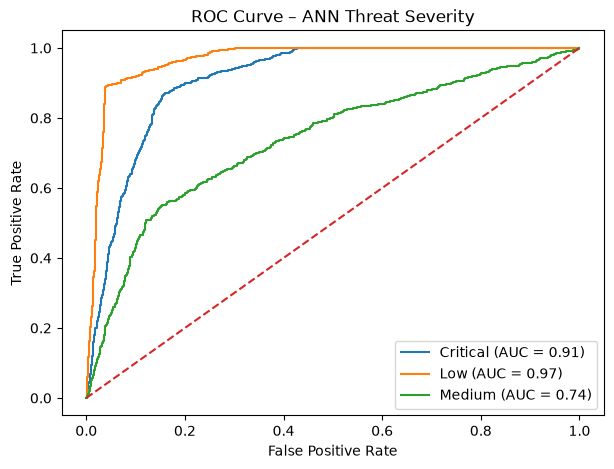

Critical AUC: 0.9102
Low AUC: 0.9657
Medium AUC: 0.7367


In [22]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder

ann_transformer = Pipeline(steps=[
    ("log1p", FunctionTransformer(np.log1p, validate=False),),
    ("scale_0_1", MinMaxScaler()), ])

normal_features = [col for col in numerical if col not in skewed_features]

ann_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("skewed", Pipeline([
            ("log1p", FunctionTransformer(np.log1p, validate=False)),
            ("scale", MinMaxScaler())]), skewed_features),
        ("normal", MinMaxScaler(), normal_features)])

X_train_ann = ann_preprocessor.fit_transform(X_train)
X_test_ann = ann_preprocessor.transform(X_test)
print("ANN input shape:", X_train_ann.shape)

# Model

ann_model = Sequential()

ann_model.add(Input(shape=(X_train_ann.shape[1],)))

ann_model.add(Dense(12, activation="relu"))
ann_model.add(Dense(8, activation="relu"))

# 3 classes
ann_model.add(Dense(3, activation="softmax"))

ann_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train 
ann_model.fit(
    X_train_ann,
    y_train,
    epochs=50,
    batch_size=10,
    validation_split=0.2
)


# EVALUATION

train_loss, train_accuracy = ann_model.evaluate(
    X_train_ann, y_train, verbose=0)

test_loss, test_accuracy = ann_model.evaluate(
    X_test_ann, y_test, verbose=0)

print(f"ANN Train Accuracy: {train_accuracy:.4f}")
print(f"ANN Test Accuracy:  {test_accuracy:.4f}")

# PREDICTIONS
y_prob_ann = ann_model.predict(X_test_ann)
y_pred_ann = y_prob_ann.argmax(axis=1)


# CLASSIFICATION 
print(classification_report(y_test, y_pred_ann, target_names=le_severity_3.classes_))
print("Test Macro-F1:", f1_score(y_test, y_pred_ann, average="macro"))

y_train_pred_ann = np.argmax(ann_model.predict(X_train_ann), axis=1)
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_ann):.4f}")
print("Test Accuracy:", accuracy_score(y_test, y_pred_ann))

# CONFUSION MATRIX
print("\nANN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ann))

# ROC CURVE
print("Average AUC:", roc_auc_score(y_test, y_prob_ann, multi_class="ovr", average="macro"))

y_test_bin = label_binarize(y_test, classes=range(len(le_severity_3.classes_)))

plt.figure(figsize=(7, 5))

for i, class_name in enumerate(le_severity_3.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_ann[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ANN Threat Severity")
plt.legend()
plt.show()


# AUC
for i, class_name in enumerate(le_severity_3.classes_):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob_ann[:, i]) 
    auc_ann = auc(fpr, tpr)
    print(f"{class_name} AUC: {auc_ann:.4f}")

### 4.3.1 Model 3 ANN Hyperparameter using RSTuner
##### Random Search was chosen for ANN optimization because the number of hyperparameter combination is uncomplicated. Since the tuning was limited to exploring between 1 and 3 hidden layers, checking 30 random setups was enough to find the best configuration without needing a more complex algorithm like Hyperband.
##### With 30 trials tuned ANN achieved 78.67% test accuracy and a 0.8760 AUC without overfitting, while reducing Medium misclassifications compare with ANN without tuning.

Trial 30 Complete [00h 00m 08s]
val_accuracy: 0.7850000262260437

Best val_accuracy So Far: 0.7875000238418579
Total elapsed time: 00h 03m 38s
--- BEST ANN PARAMETERS ---
num_layers: 3
units_0: 8
dropout_0: 0.0
learning_rate: 0.01
units_1: 40
dropout_1: 0.2
units_2: 40
dropout_2: 0.0
Epoch 1/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 499us/step - accuracy: 0.7243 - loss: 0.6772 - val_accuracy: 0.7713 - val_loss: 0.5946
Epoch 2/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 408us/step - accuracy: 0.7577 - loss: 0.6330 - val_accuracy: 0.7421 - val_loss: 0.6005
Epoch 3/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - accuracy: 0.7707 - loss: 0.6207 - val_accuracy: 0.7500 - val_loss: 0.5950
Epoch 4/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - accuracy: 0.7722 - loss: 0.6163 - val_accuracy: 0.7483 - val_loss: 0.5879
Epoch 5/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step - accuracy: 0.7693 - loss: 0.6168 - val_accuracy: 0.7837 - val_loss: 0.5663
Epoch 6/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy:

E0000 00:00:1791234252.742199 9971446 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Test Accuracy: 0.7773333333333333

ANN RS Confusion Matrix:
 [[1168    1  261]
 [   0  811  100]
 [ 221   85  353]]
Average AUC: 0.865979844192364


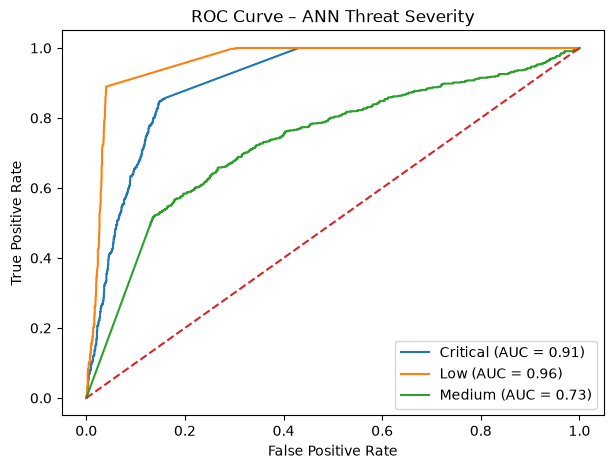

Macro ROC-AUC: 0.865979844192364


In [23]:
# HYPERPARAMETER 
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from tensorflow import keras

# ANN MODEL BUILDER
def model_builder(hp):
    model = keras.Sequential([keras.layers.Input(shape=(X_train_ann.shape[1],))])

    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(keras.layers.Dense(hp.Int(f"units_{i}", 8, 64, step=8), activation="relu"))
        model.add(keras.layers.Dropout(hp.Float(f"dropout_{i}", 0.0, 0.3, step=0.1)))

    model.add(keras.layers.Dense(3, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice("learning_rate", [0.001, 0.003, 0.01])),
        loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model


# HYPERPARAMETER TUNING
from keras_tuner import RandomSearch

RStuner = RandomSearch(
    model_builder,
    objective="val_accuracy",
    max_trials=30,
    directory="keras_tuner_RS",
    project_name="cyber_threat_severity",
    overwrite=True
)

RStuner.search(
    X_train_ann,
    y_train,
    validation_split=0.2,
    batch_size=10,
    epochs=50,
    callbacks=[EarlyStopping(monitor="val_loss", 
                             patience=5, restore_best_weights=True)])

best_hps = RStuner.get_best_hyperparameters(1)[0]
best_ann = RStuner.hypermodel.build(best_hps)

print("--- BEST ANN PARAMETERS ---")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")

# FINAL TRAINING

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights based on how rare or common each threat class is
weights = compute_class_weight(
    class_weight="balanced", 
    classes=np.unique(y_train), 
    y=y_train
)
class_weight_dict = dict(enumerate(weights))

# FINAL TRAINING WITH CLASS WEIGHTS
best_ann.fit(
    X_train_ann, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=10,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1)

# TEST EVALUATION
y_prob_ann_rs = best_ann.predict(X_test_ann, verbose=0)
y_pred_ann_rs = y_prob_ann_rs.argmax(axis=1)

print(classification_report(y_test, y_pred_ann_rs, target_names=le_severity_3.classes_))
print("Test Macro-F1:", f1_score(y_test, y_pred_ann_rs, average="macro"))

y_train_pred_ann_rs = np.argmax(best_ann.predict(X_train_ann), axis=1)
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_ann_rs):.4f}")
print("Test Accuracy:", accuracy_score(y_test, y_pred_ann_rs))

# CONFUSION MATRIX
print("\nANN RS Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ann_rs))

# ROC CURVE
print("Average AUC:", roc_auc_score(y_test, y_prob_ann_rs, multi_class="ovr", average="macro"))

y_test_bin = label_binarize(y_test, classes=range(len(le_severity_3.classes_)))

plt.figure(figsize=(7, 5))

for i, class_name in enumerate(le_severity_3.classes_):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_ann_rs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ANN Threat Severity")
plt.legend()
plt.show()

print("Macro ROC-AUC:", roc_auc_score(y_test, y_prob_ann_rs, multi_class="ovr", average="macro"))


## 5. EVALUATION
##### Based on the metrics provided, the XGBoost Grid Search (XGB Grid) model is the overall best performing model. 
##### 1. While Random Forest Grid Search (RF Grid) has the highest Test Accuracy (79.77%), the XGBoost Grid model offers a much better balance because it achieves the highest overall AUC (0.8766). 
##### 2. nearly identical test accuracy (79.73%) and train accuracy (79.70%), proves it avoids overfitting.
##### 3. In the confusion matrix XGB Grid balances its predictions well across all categories. For Medium Severity, XGB Grid model accurately identifies 322 cases, with its remaining errors divide between Critical (255) and Low (82).

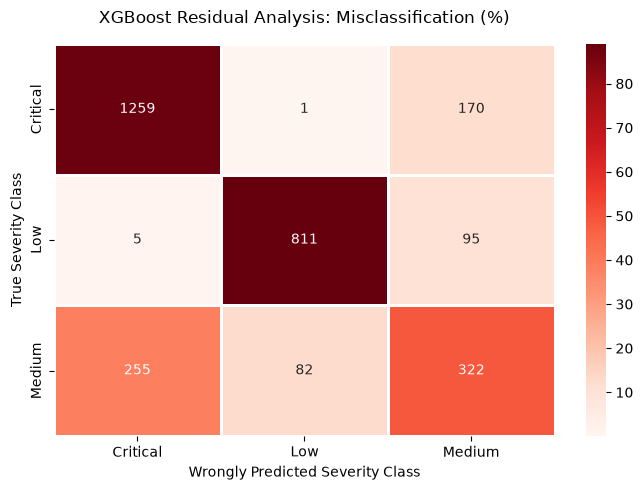

In [24]:
cm = confusion_matrix(y_test, y_pred_xgb_grid)
classes = le_severity_3.classes_
error_matrix = cm.copy().astype(float)

row_totals = cm.sum(axis=1)[:, np.newaxis]
error_matrix_perc = np.divide(
    error_matrix, row_totals, out=np.zeros_like(error_matrix), where=row_totals != 0
) * 100

# 3. Plot the Residual Error Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    error_matrix_perc,
    annot=cm,  
    fmt="d",
    cmap="Reds",  
    xticklabels=classes,
    yticklabels=classes,
    linewidths=1,
)

plt.title("XGBoost Residual Analysis: Misclassification (%)", pad=15)
plt.xlabel("Wrongly Predicted Severity Class")
plt.ylabel("True Severity Class")
plt.tight_layout()
plt.show()


### 5.1 Local LIME Analysis
##### LIME Transparency Analysis uses to explain which features contributes most to selected target classes. The selected model gives prediction but no explanation why it behaves that way. LIME used on specific event to explain which features act as positive or negative support for each target severity classes and explain exactly why the model made its decision.
##### LIME Plot shows:
##### Green Bars: Features that align with the class prediction and vote YES. They push the model to choose specific class.
##### Red Bars: Features that disagree with the class prediction and vote NO. They push the model away from specific class.
##### Critical Class: Chart is mostly red, the model is confident which features with low score push the model away from this class.
##### Low Class: Chart is mostly green, the model is confident which features with low score push the model to choose this class.
##### Medium Class: This chart has a mix of red and green. It shows the model sees confusing clues, meaning it is unsure about this class.

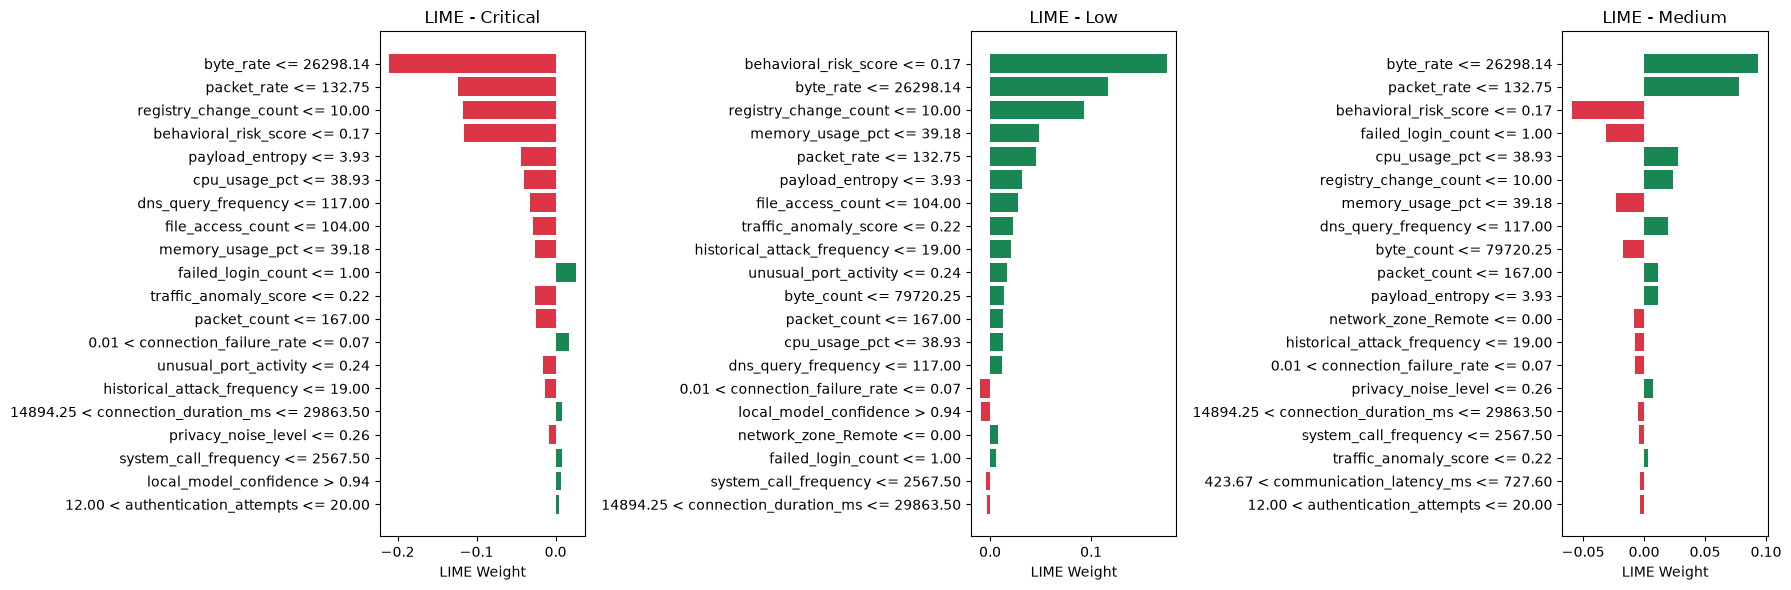

In [25]:
# LIME Transparency Analysis

from lime import lime_tabular

# Best XGBoost pipeline
best_pipeline = xgb_grid.best_estimator_
preprocessor = best_pipeline.named_steps["preprocessor"]
best_xgb = best_pipeline.named_steps["classifier"]

X_train_lime = preprocessor.transform(X_train)
X_test_lime = preprocessor.transform(X_test)

# Feature and class names
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.replace("remainder__", "")
        .replace("num__", "")
        .replace("cat__", "")
    for name in feature_names]

class_names = list(le_severity_3.classes_)

# LIME explainer
explainer_lime = lime_tabular.LimeTabularExplainer(
    X_train_lime,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Select one example
example_index = 6
example_x = X_test_lime[example_index]

# Explain all three classes
explanation = explainer_lime.explain_instance(
    example_x,
    best_xgb.predict_proba,
    num_features=20,
    labels=[0, 1, 2]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.replace("remainder__", "") for name in feature_names]

# Plot the explanations side-by-side
for i, class_index in enumerate([0, 1, 2]):
    values = explanation.as_list(label=class_index)
    
    features = [x[0] for x in values]
    weights = [x[1] for x in values]
    colors = ['#dc3545' if w < 0 else '#198754' for w in weights]
    
    axes[i].barh(features, weights, color=colors)
    axes[i].set_title(f"LIME - {class_names[class_index]}")
    axes[i].set_xlabel("LIME Weight")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()


### 5.2 SHAP Analysis
##### It calculates the average contribution of a feature across all possible feature combinations. It shows which features are the most important and the model cares about.

### 5.2.1 SHAP Bar Analysis
##### The stacked bar chart shows the average overall impact of each feature across all three target classes combined:
##### Longer Bars: The features at the top with longer bars (like byte_rate and behavioral_risk_score) are the most powerful drivers the model uses to determine threat severity.
##### Shorter Bars: Features at the very bottom (like threat_indicator_count or process_count) has almost no length, meaning the model mostly ignores them when deciding threat severity class.
##### Colors: Shows which class driven most by the specific feature  

/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


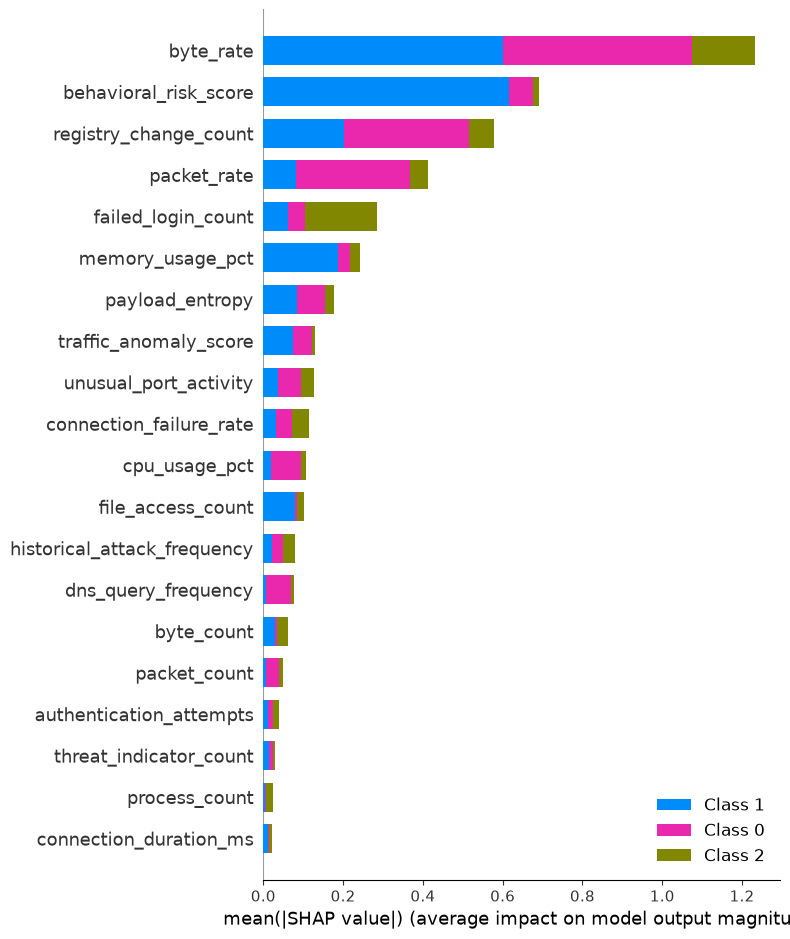

In [26]:
# SHAP Transparency Analysis
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

best_pipeline = xgb_grid.best_estimator_

preprocessor = best_pipeline.named_steps["preprocessor"]
best_xgb = best_pipeline.named_steps["classifier"]
X_train_shap = preprocessor.transform(X_train)
X_test_shap = preprocessor.transform(X_test)

import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_shap)
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar"
)


### 5.2.2 SHAP Summary Plot
##### this side by side plot shows how high or low feature values push the model toward or away from each specific severity class.
##### Red Dots mean a feature value is High.
##### Blue Dots mean a feature value is Low.
##### Right direction (Positive): Pushes model to choose this severity class.
##### Left direction (Negative): Pushes model away from this severity class.

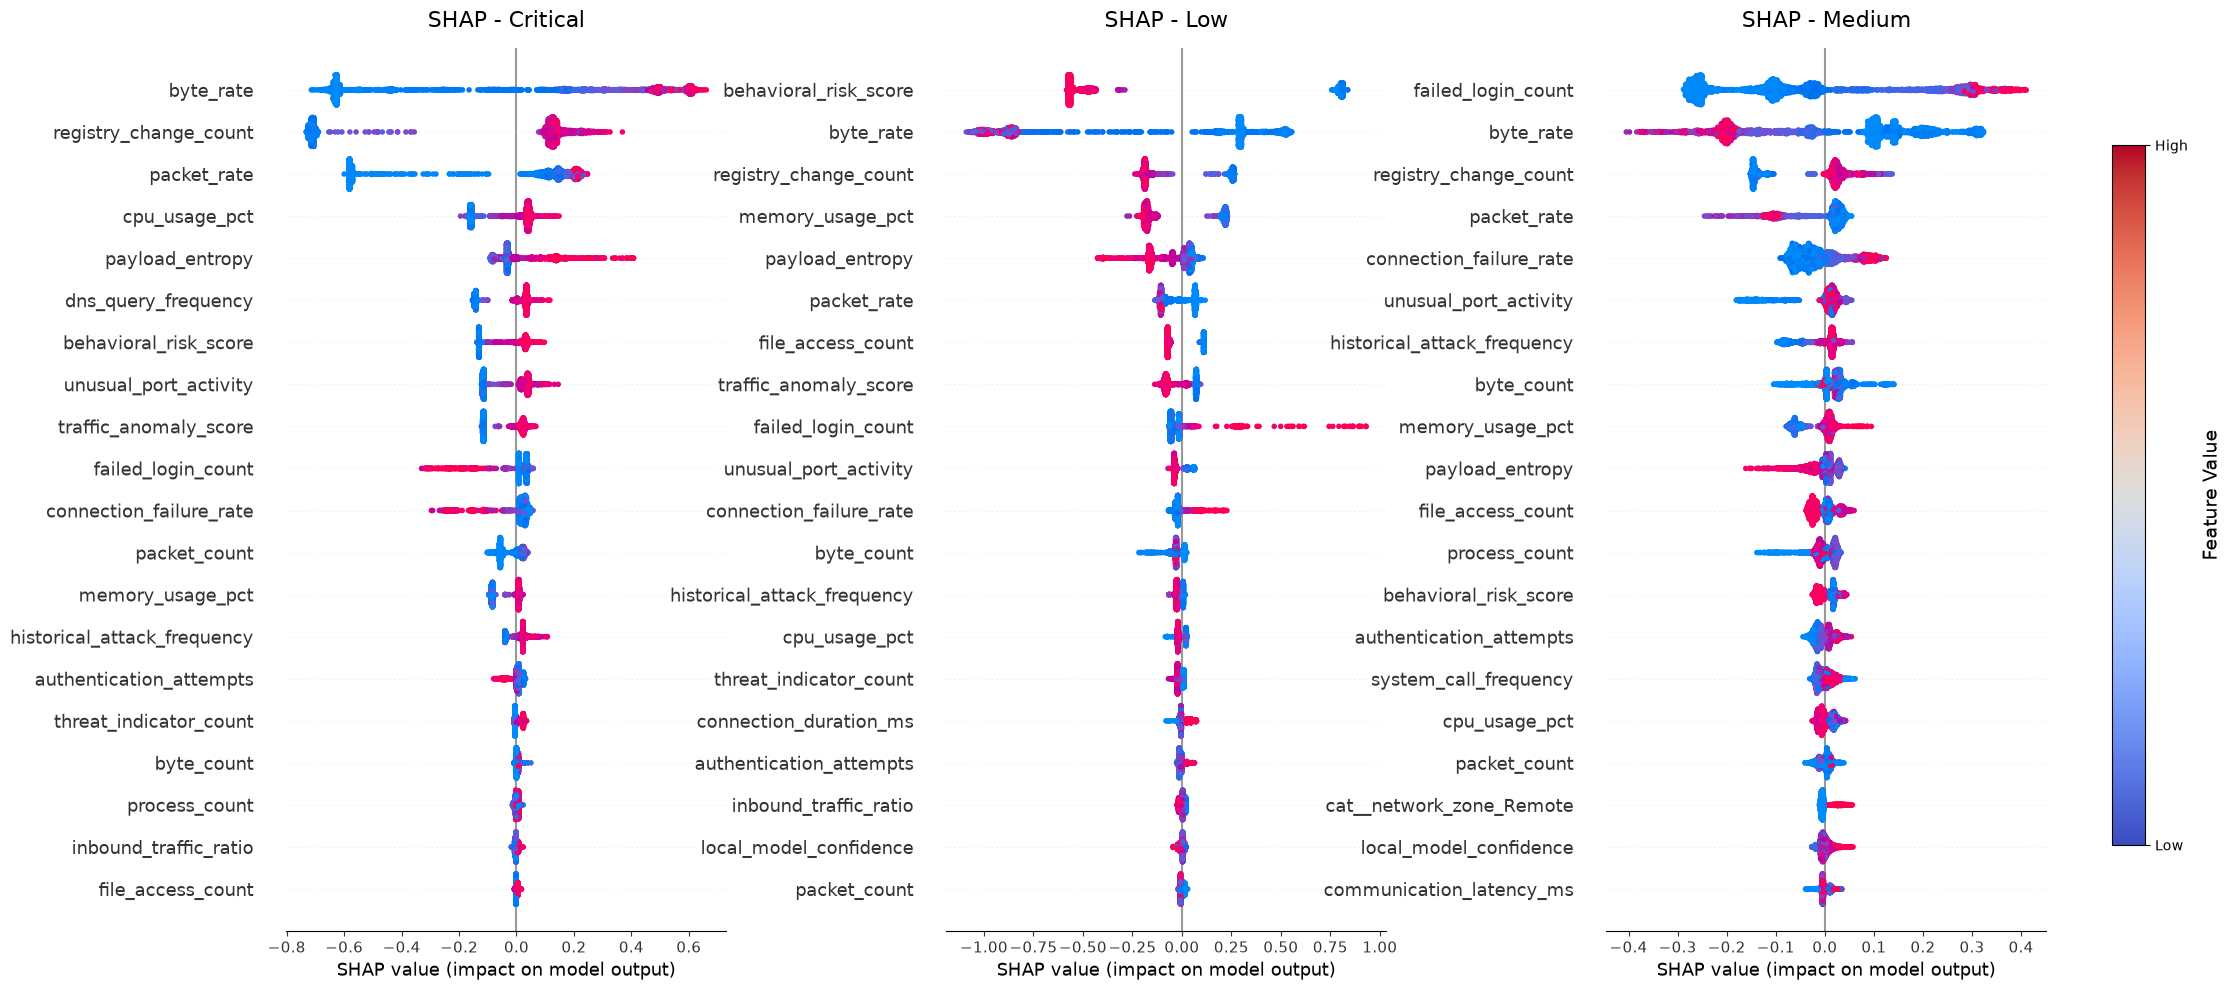

In [27]:
import shap
import matplotlib.cm as cm
import matplotlib.colors as colors
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Create a massive horizontal canvas. 
fig, axes = plt.subplots(1, 3, figsize=(22, 10), sharey=False)

for class_index in range(3):
    ax = axes[class_index]
    class_name = le_severity_3.classes_[class_index]
    ax.set_title(f"SHAP - {class_name}", fontsize=16, pad=15)
    
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, class_index], X_test_shap,
        feature_names=feature_names, plot_size=None,   
        color_bar=False, show=False)

# 5. FIXED COLORBAR MAP: Using modern matplotlib syntax
sm = cm.ScalarMappable(cmap=plt.colormaps["coolwarm"], norm=colors.Normalize(vmin=0, vmax=1))
sm.set_array([])

cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7]) 
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Feature Value", fontsize=14, labelpad=10)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Low", "High"])

# 6. Clean up the padding between your 3 side-by-side plots
plt.subplots_adjust(wspace=0.5, left=0.1, right=0.9)
plt.show()

### 5.3 Future Work
##### Future research could investigate stricter decision boundaries for the Medium class. Since most classification errors occurred between Medium and the other severity levels, adjusting class thresholds may improve the detection of Medium threats and overall model performance.


## 6. DEPLOYMENT

### 6.1 Predict Severity Level with existed ID on dataset
##### A prediction function was created to estimate the severity level of an event based on its event ID. The model returns the probability of the event belonging to each severity class (Low, Medium, and Critical), helping users assess threat severity.
##### This allows users to understand the model's confidence and supports threat prioritization decisions.

In [28]:
feature_columns = X.columns.tolist()

def predict_threat_probability(event_id, target_model):
    row = df[df["event_id"] == event_id]

    if row.empty:
        print(f"Error: event_id {event_id} not found.")
        return None

    X_single = row[feature_columns]
    probabilities = target_model.predict_proba(X_single)[0]
    return dict(zip(le_severity_3.classes_, probabilities))

print(predict_threat_probability("EVT_004660", xgb_grid))

{'Critical': np.float32(0.28154236), 'Low': np.float32(0.14795956), 'Medium': np.float32(0.57049805)}


### 6.2 Predict Severity Level with new value on these features (byte_rate, behavioral_score, packet_rate, failed_login)
##### A second prediction function was developed to allow users to enter new threat characteristics, including network zone, behavioral risk score, historical attack frequency, and failed login count. 
##### Based on your LIME bar charts and SHAP beeswarm plots, These features were chosen because they carry high global importance and clear directionality patterns.
##### The model then estimates the probability of each severity level. This demonstrates how the model can support future threat assessment for new incidents that are not already stored in the dataset.

In [29]:
def predict_raw_threat_probability(
    byte_rate,
    behavioral_score,
    packet_rate,
    failed_logins,
    target_model=xgb_grid
):
    features = target_model.best_estimator_.feature_names_in_

    # Start with a copy of one real row to preserve correct data types
    X_single = df[features].iloc[[0]].copy()

    # Replace only the values entered by the user
    X_single.loc[0, "byte_rate"] = byte_rate
    X_single.loc[0, "behavioral_risk_score"] = behavioral_score
    X_single.loc[0, "packet_rate"] = packet_rate
    X_single.loc[0, "failed_login_count"] = failed_logins

    probabilities = target_model.predict_proba(X_single)[0]

    return dict(zip(le_severity_3.classes_, probabilities))

print(predict_raw_threat_probability(
    byte_rate=10000,
    behavioral_score=0.70,
    packet_rate=70,
    failed_logins=4
))


{'Critical': np.float32(0.28205886), 'Low': np.float32(0.17083888), 'Medium': np.float32(0.5471023)}


### 6.3 Deploy model to an App
##### To make the model accessible to stakeholders, the final XGBoost model can be deployed in different ways depending on organizational requirements.

In [30]:
joblib.dump(xgb_grid, "model/xgb_grid_model.joblib")
joblib.dump(le_severity_3, "model/label_encoder.joblib")

['model/label_encoder.joblib']

#### 1. Web Application Deployment
##### The final XGBoost model was saved and deployed as a web application. This allows stakeholders to access the model through a web browser, enter cybersecurity event information, and receive threat severity predictions in real time.
#### 2. Cloud Deployment
##### The final XGBoost model was saved and deployed on a cloud platform. This allows stakeholders to access the prediction service remotely and perform threat severity assessments from different locations through an internet connection.

## 7. References